In [94]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import datetime

In [95]:
def dateCleaner(date):
    date = datetime.datetime.strptime(date, '%m/%d/%y')
    return date.date()
print(dateCleaner('2/28/24'))

2024-02-28


In [96]:
def timeCleaner(time):
    '''takes in the shift time from the database and cleans it up.
    
    returns a datetime object with ONLY the time as the date is its own column
    
    if the redundant date stuff in the database is ever cleaned up, might need to take in time AND date column'''
    # the first param strips off that weird subtraction and also reduces the decimal to 6 places
    time = datetime.datetime.strptime(' '.join(time.split()[:2])[:-1], '%Y-%m-%d %H:%M:%S.%f')
    return time
    
print(timeCleaner('2024-02-16 10:00:00.0000000 -06:00'))

2024-02-16 10:00:00


In [97]:
def preprocess(file):
    '''any dataset cleaning can go on here.
    currently the DF is simply generated'''
    DF = pd.read_csv(file)
    DF['Signup Date'] = DF['Signup Date'].apply(dateCleaner)
    DF['Event Date'] = DF['Event Date'].apply(dateCleaner)
    DF['Shift Start Time'] = DF['Shift Start Time'].apply(timeCleaner)
    DF['Shift End Time'] = DF['Shift End Time'].apply(timeCleaner)

    # any new columns go here
    DF['Shift Length'] = (DF['Shift End Time'] - DF['Shift Start Time']) / np.timedelta64(1, 'h')

    DF = DF.sort_values(by=['Event Date'])
    return DF

In [98]:
def shiftLength(data):
    '''generates a graph of shift lengths'''
    
    fig,ax = plt.subplots(1,1)
    fig.set_size_inches(20, 10)
    ax.set_title("Histogram of Shift Lengths")
    ax.set_xlabel('Hours Worked')
    ax.set_ylabel('# of Shifts')
    bins = [x/4 for x in range(9*4+1)]
    ax.grid(axis='y', linestyle='--')
    ax.set_xticks(bins, bins, rotation='vertical')
    ax.hist(data, density=False, bins=bins, edgecolor='black')
    #ax.hist(data, density=False, bins=bins, edgecolor='black', align='left')
    plt.show()


In [99]:
def dupOrientationCheck(IDs, DF):
    '''VANIDs with multiple orientations on file. Very few of these, should be cleaned earlier perhaps
    needs more investigating.'''
    for ID in IDs:
        tmp = DF[DF['VANID'] == ID]
        tmp = tmp[tmp['Event Name'].str.contains('orientation', case=False)]
        if len(tmp) > 1:
            if len(tmp[tmp['Event Name'].str.contains('orientation', case=False)]) != 0:
                print(tmp)


In [100]:
def addDict(day, d):
    try:
        d[day] += 1
    except KeyError:
        d[day] = 1

def shiftDatesAfterOnboarding(IDs, DF):
    '''need to account for multiple or missing orientations'''
    # for each VANID find all shifts, and collect the # of days since orientation
    # in a dict of days since orientation, increment the counter for that given day

    shiftTracker = {}

    for ID in IDs:
        tmp = DF[DF['VANID'] == ID]
        if len(tmp) > 1:
            startDate = tmp['Event Date'].iloc[0] # starting point, should be last orientation but DF needs some cleanup first            
            for i in range(1, len(tmp)): # incremenets the hits on each day after first shift on overall tracker
                delta = (tmp['Event Date'].iloc[i] - startDate)
                addDict(delta.days, shiftTracker)
    
    #print(shiftTracker)
    # shifts charted, now gen graph
    fig,ax = plt.subplots(1,1)
    fig.set_size_inches(20, 10)
    ax.set_title('Histogram of Shifts from Orientation*')
    ax.set_xlabel('Days Since Joining (approx)')
    ax.set_ylabel('# of People Volunteering')
    X = list(shiftTracker.keys())
    X.sort()
    Y = [shiftTracker[x] for x in X]
    #ax.bar(['a', 'b', 'c'], [1, 2, 3])
    #ax.plot(X, Y, lw=.75)
    #ax.bar(X, Y)
    bins = [x for x in range(0, max(X), 15)]
    ax.set_xticks(bins, bins, rotation='vertical')
    ax.grid(axis='y', linestyle='--')
    plt.axvline(365, color='red', linestyle='--') # should add an auotmated thing to future proof this
    plt.axvline(365*2, color='red', linestyle='--')
    plt.axvline(365*3, color='red', linestyle='--')
    ax.hist(X, bins=bins, edgecolor='black')
    #ax.bar(data, density=False, bins=bins, edgecolor='black', align='left')
    plt.show()

# Orientation does not have a consistant event type!

It appears to jump between "Training", "Vol Orientatio", "Vol Recruitment", "Group Volunteer"

In [ ]:
def onboardingDayPopularity(df):
    '''generates hist of each shit type'''

    df = df[df['Event Type'] == 'Vol Orientatio']
    data = [_.weekday() for _ in df['Event Date']]
    # debuging the date bug where orientation only shows up on like 4 days
    dataDebug = [_ for _ in df['Event Date']]
    print("onboardingDayPopularity:")
    for i in range(len(dataDebug)):
        print(f'{dataDebug[i]}\t{data[i]}')


    fig,ax = plt.subplots(1,1)
    fig.set_size_inches(20, 10)
    ax.set_title("Barplot of Shifts by Popularity\nNOTE: highly influenced by what days people are invited to, currently not represented")
    ax.set_xlabel('Shift Type')
    ax.set_ylabel('# of Shifts')
    ax.grid(axis='y', linestyle='--')
    daysOfWeek = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    ax.set_xticks([_ for _ in range(7)], daysOfWeek, rotation='horizontal')
    plt.xlim(xmin=-.5, xmax = 6.5) # dumb hack to get outlier bins to render as desired
    ax.hist(data, bins=[x for x in range(7)], range=[0, 10], align='left', rwidth=.75, edgecolor='black')
    plt.show()

In [102]:
def shiftDayPopularity(col):
    '''generates bar of each shift type'''
    # generate array of which day of week each shift is on
    # note that sat, sun, mon, ... is 0, 1, 2, ...
    data = [_.weekday() for _ in col]
    # print(np.bincount(data))

    fig,ax = plt.subplots(1,1)
    fig.set_size_inches(20, 10)
    ax.set_title("Barplot of Shifts by Day")
    ax.set_xlabel('Day of the Week')
    ax.set_ylabel('# of Shifts')
    ax.grid(axis='y', linestyle='--')
    daysOfWeek = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    ax.set_xticks([_ for _ in range(7)], daysOfWeek, rotation='horizontal')
    ax.bar([_ for _ in range(7)], np.bincount(data), edgecolor='black')
    plt.show()

In [103]:
def shiftTypePopularity(col):
    '''generates bar of each shift type'''
    data = col.value_counts()
    
    fig,ax = plt.subplots(1,1)
    fig.set_size_inches(20, 10)
    ax.set_title("Barplot of Shifts by Popularity")
    ax.set_xlabel('Shift Type')
    ax.set_ylabel('# of Shifts')
    ax.grid(axis='y', linestyle='--')
    ax.bar(data.axes[0], data.values, edgecolor='black')
    plt.show()

# GOALS:
- volunteer onboarding, where do we lose them? ✅

- are certain days/times better for onboarding? ✅

- check what days people volunteer on ✅

- popularity of jobs ✅

- graph how many volunteers do we have, what is their participation rate (use VANID)
- do they vol regularly (same as above?)

- shelter shift cross reference with other DB for more details

- meal train volunteers, how many meals do people bring? Track them over time.
-- integrate more numbers from meal train data
-- need meal train data

- transfer excel data to site via API

onboardingDayPopularity:
2025-01-09	3
2025-01-09	3
2025-01-09	3
2025-01-09	3
2025-01-09	3
2025-01-09	3
2025-02-01	5
2025-02-01	5
2025-02-01	5
2025-02-01	5
2025-02-01	5
2025-02-01	5
2025-02-01	5
2025-02-01	5
2025-02-01	5
2025-02-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-01	5
2025-03-20	3
2025-03-20	3
2025-03-20	3
2025-03-20	3
2025-03-20	3
2025-03-20	3
2025-03-20	3
2025-03-20	3
2025-03-20	3
2025-03-20	3
2025-03-20	3
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-03-25	1
2025-05-03	5
2025-05-03	5
2025-05-03	5
2025-05-03	5
2025-05-03	5
2025-05-03	5
2025-05-03	5
2025-05-03	5
2025-05-03	5


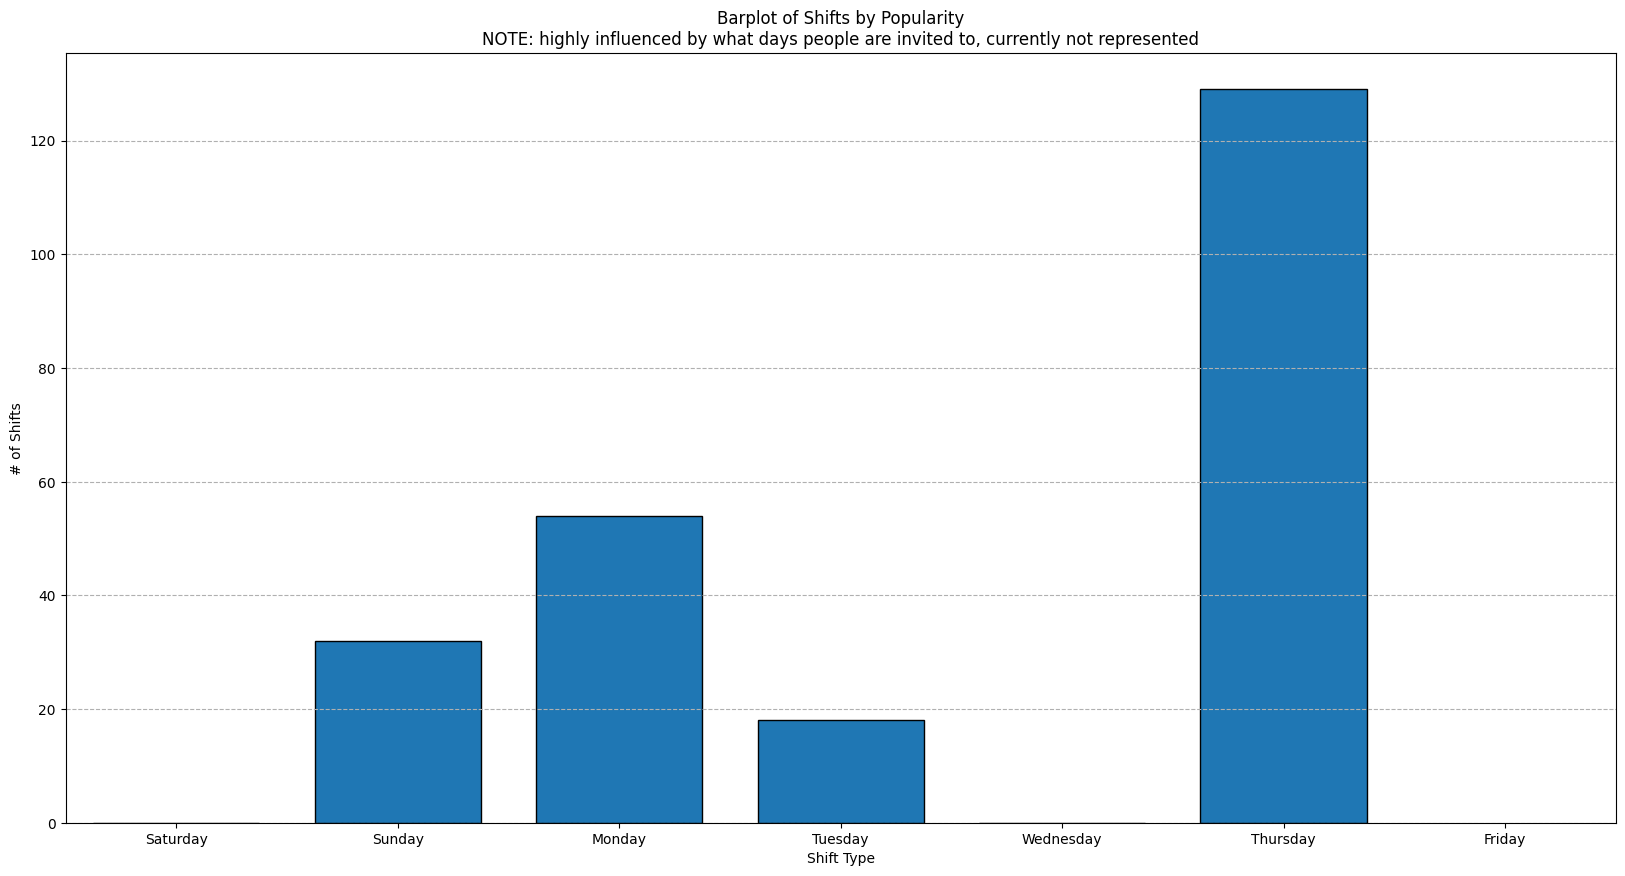

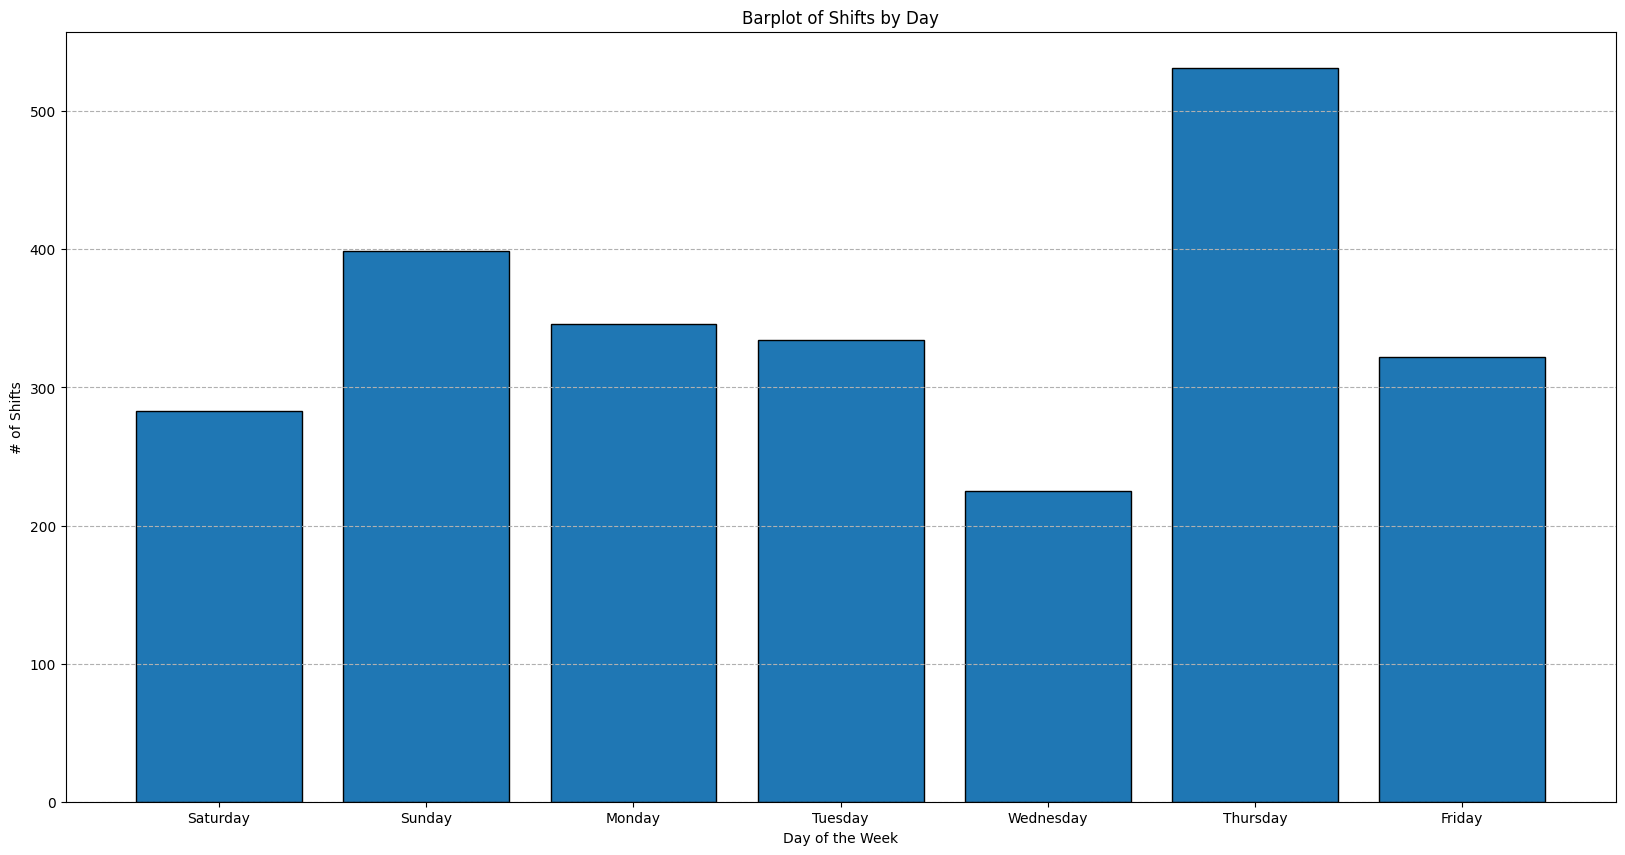

In [104]:
def main():
    '''
    DF columns reminder:    
    VANID,Signup Date,Status,Role,Event Name,Event Type,Event Date,Shift Start Time,Shift End Time,Location Name

    '''
    fileName = os.path.join('databases', 'EventParticipantReport-Sisu-2023-Present.csv') 
    DF = preprocess(fileName)
    IDs = list(set(DF['VANID']))
    IDs.sort()

    # my sanity checks
    #dupOrientationCheck(IDs, DF)

    # graphs
    # shiftLength(DF['Shift Length'])
    # shiftDatesAfterOnboarding(IDs, DF)
    onboardingDayPopularity(DF) # LOOK INTO WHY THIS DISTRO IS ODD, confirmed on other days
    shiftDayPopularity(DF['Event Date'])
    # shiftTypePopularity(DF['Event Type'])

    
main()